### EEG Data Preprocessing and Preparation for Graph Creation

In this file, we do the following (for file chb01_01):
1) load data
2) filter data (1-45 Hz)
4) re-reference data
5) transform into 2D array (rows = time points, columns = electrodes)
6) segment the data into 5-second windows
7) get average power from 5-second windows in order to reduce data points

Eye artifact removal (usually also part of EEG preprocessing) is not possible since no data from eye electrodes is available.

Next step: depends on graph type we want to construct, maybe HVG

In [1]:
import mne
from mne import set_bipolar_reference
from mne.io import read_raw
from mne.preprocessing import ICA
from pipeline.datasets import get_erpcore
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

## loading data

In [3]:
# load file 01
raw_01 = mne.io.read_raw_edf('chb01_01.edf', preload=True)
raw_data_01 = mne.io.read_raw_edf('chb01_01.edf', preload=True)._data
# print(raw_data_01)

Extracting EDF parameters from chb01_01.edf...
Setting channel info structure...
Creating raw.info structure...


C:\Users\marin\AppData\Local\Temp\ipykernel_16440\1048083340.py:2: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw_01 = mne.io.read_raw_edf('chb01_01.edf', preload=True)


Reading 0 ... 921599  =      0.000 ...  3599.996 secs...
Extracting EDF parameters from chb01_01.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 921599  =      0.000 ...  3599.996 secs...


C:\Users\marin\AppData\Local\Temp\ipykernel_16440\1048083340.py:3: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw_data_01 = mne.io.read_raw_edf('chb01_01.edf', preload=True)._data


Number of channels:  23
Number of samples:  921600


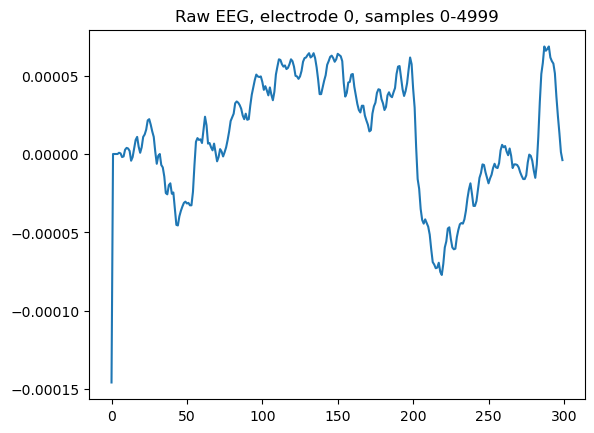

In [4]:
# test

print("Number of channels: ", str(len(raw_data_01)))
print("Number of samples: ", str(len(raw_data_01[0])))

plt.plot(raw_data_01[0,:300])
plt.title("Raw EEG, electrode 0, samples 0-4999")
plt.show()

## filtering data

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 45 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 45.00 Hz
- Upper transition bandwidth: 11.25 Hz (-6 dB cutoff frequency: 50.62 Hz)
- Filter length: 845 samples (3.301 s)

Effective window size : 8.000 (s)
Plotting power spectral density (dB=True).


C:\Users\marin\AppData\Local\Temp\ipykernel_16440\3641271040.py:6: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  raw_01.compute_psd(fmax=60).plot()
C:\Users\marin\anaconda3\Lib\site-packages\mne\viz\utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


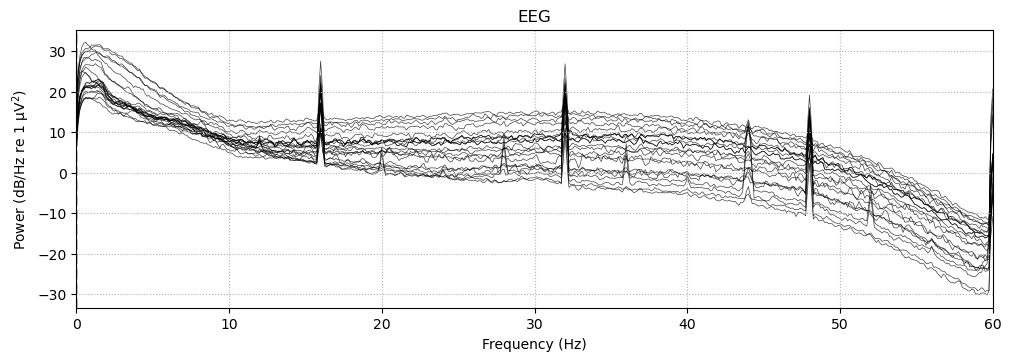

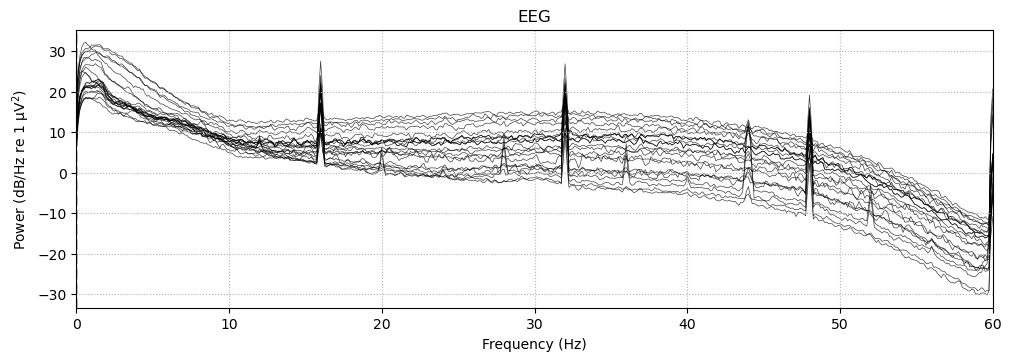

In [5]:
# Apply bandpass filter from 1-45 Hz
filtered_raw_01 = raw_01.copy().filter(l_freq=1, h_freq=45)

# visualize results: power spectral density before and after filtering

# before filtering
raw_01.compute_psd(fmax=60).plot()

Effective window size : 8.000 (s)
Plotting power spectral density (dB=True).


C:\Users\marin\AppData\Local\Temp\ipykernel_16440\3311281567.py:2: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  filtered_raw_01.compute_psd(fmax=60).plot()
C:\Users\marin\anaconda3\Lib\site-packages\mne\viz\utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


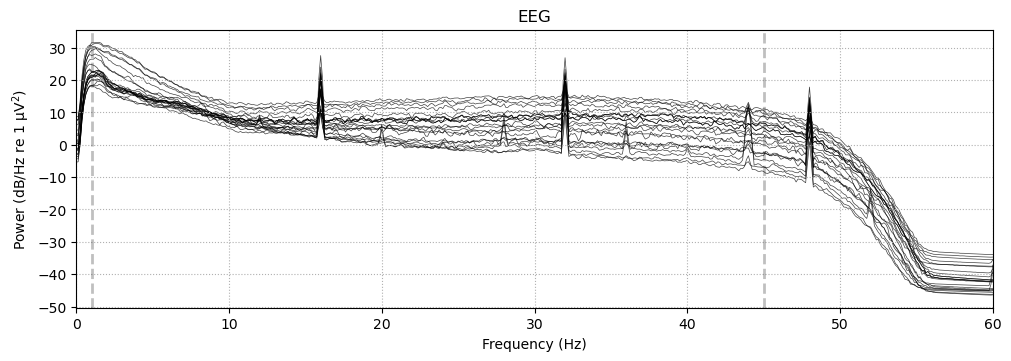

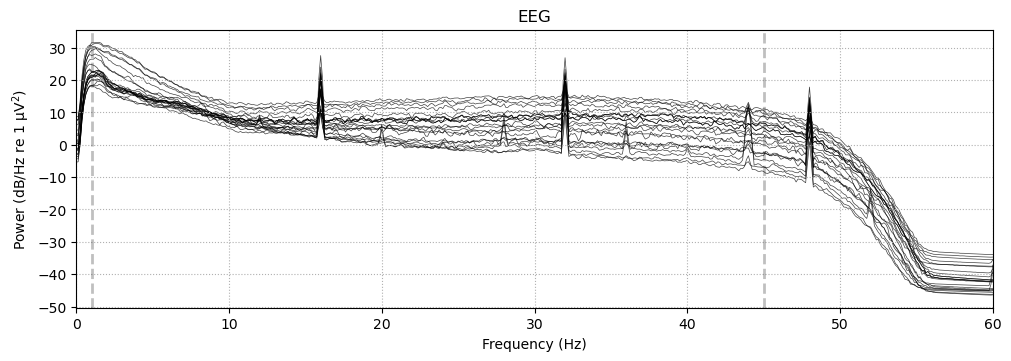

In [6]:
# after filtering
filtered_raw_01.compute_psd(fmax=60).plot()

## re-referencing data

EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.


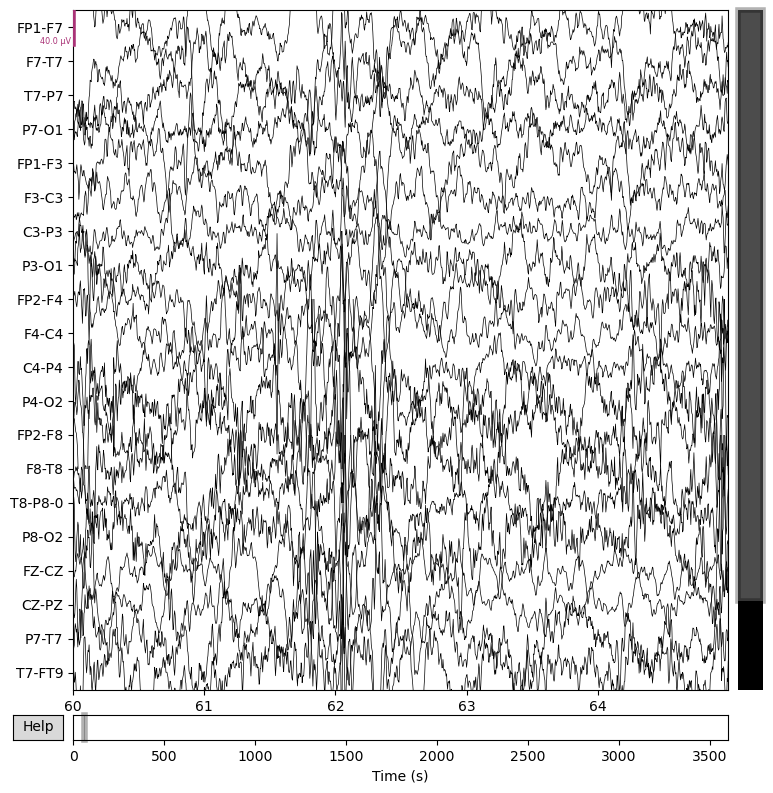

In [13]:
raw_01_reref = raw_01.set_eeg_reference('average')
_ = raw_01_reref.plot(start=60.0, duration=5.0)

## creating an array

In [49]:
# get electrode names
electrode_names = raw_01.ch_names

# print names to verify
# print(electrode_names)

# get sampling frequency
sfreq = raw_01.info['sfreq']

# calculate time points in seconds
n_samples = len(raw_01.times)
time_marks = np.arange(n_samples) / sfreq

# electrode data (rows = electrodes, columns = time points)
electrode_data = raw_01.get_data()

# electrode names
electrode_names = raw_01.ch_names

#  DataFrame, transpose electrode_data so each column is an electrode
df = pd.DataFrame(electrode_data.T, columns=electrode_names)

# time as index
df.index = time_marks
df.index.name = 'Time (s)'

# check
# display(df)
#print(df.iloc[:20,:7])

## segmenting into 5 second windows

In [21]:
window_size = 5  # seconds

# add window labels (0-5s = 0, 5-10s = 1, etc.) to df
df['window'] = (df.index // window_size).astype(int)

# check -> 720*5 seconds = 3600s = 1h = length of recording
display(df)

,FP1-F7,F7-T7,T7-P7,P7-O1,FP1-F3,F3-C3,C3-P3,P3-O1,FP2-F4,F4-C4,...,T8-P8-0,P8-O2,FZ-CZ,CZ-PZ,P7-T7,T7-FT9,FT9-FT10,FT10-T8,T8-P8-1,window
Time (s),,,,,,,,,,,,,,,,,,,,,
0.000000,-1.026575e-04,-6.124117e-05,4.926474e-07,1.026066e-05,-1.276636e-04,-6.749270e-05,5.519350e-05,-1.318257e-05,-9.601529e-05,4.190901e-05,...,8.801401e-05,1.180995e-04,-6.280406e-05,1.278675e-04,8.645113e-05,-1.396401e-05,-2.214365e-04,1.380262e-04,8.801401e-05,0
0.003906,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0
0.007812,3.552655e-24,3.552655e-24,3.552655e-24,3.552655e-24,3.552655e-24,3.552655e-24,3.552655e-24,3.552655e-24,3.552655e-24,3.552655e-24,...,3.552655e-24,-3.907204e-07,3.552655e-24,3.552655e-24,3.552655e-24,3.552655e-24,3.907204e-07,3.552655e-24,3.552655e-24,0
0.011719,8.493922e-08,4.756596e-07,8.493922e-08,4.756596e-07,8.493922e-08,8.493922e-08,8.493922e-08,8.493922e-08,8.493922e-08,8.493922e-08,...,8.493922e-08,-2.259383e-06,8.493922e-08,8.493922e-08,8.493922e-08,-6.965016e-07,1.647821e-06,8.493922e-08,8.493922e-08,0
0.015625,6.795137e-08,6.795137e-08,6.795137e-08,-3.227690e-07,6.795137e-08,6.795137e-08,6.795137e-08,6.795137e-08,6.795137e-08,6.795137e-08,...,6.795137e-08,8.493922e-07,6.795137e-08,6.795137e-08,6.795137e-08,4.586718e-07,-2.276371e-06,6.795137e-08,6.795137e-08,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3599.980469,3.720338e-06,9.852949e-07,3.810373e-05,-4.094070e-06,-1.776928e-05,-2.921909e-06,2.872644e-05,3.185221e-05,-1.112704e-05,-2.531189e-06,...,1.348835e-05,-2.714657e-05,6.455380e-06,9.852949e-07,-5.801348e-05,-5.293412e-05,2.208420e-05,9.852949e-07,1.348835e-05,719
3599.984375,-8.799703e-06,1.425280e-05,4.707331e-05,-1.739555e-05,-3.224293e-05,1.620640e-05,4.277539e-05,7.219833e-06,-7.627542e-06,2.140468e-06,...,8.782715e-06,-3.849445e-05,2.167649e-05,1.151776e-05,-6.076551e-05,-3.497797e-05,2.480225e-05,-6.064660e-06,8.782715e-06,719
3599.988281,-1.539099e-05,1.977385e-05,4.477995e-05,-2.164251e-05,-3.883421e-05,3.423050e-05,3.618411e-05,-2.887933e-06,-6.013696e-06,-2.106493e-06,...,1.313160e-05,-2.125179e-05,2.094601e-05,1.508520e-05,-5.211870e-05,-1.578171e-05,-2.887933e-06,-1.109306e-05,1.313160e-05,719


In [37]:
# create a new array -> each cell contains an array of values for that 5s window
df_windows = df.groupby('window').agg(list)
#display(df_windows)

df_windows.iloc[:5, 1:2]
print(df_windows.shape) # 720 windows, 23 electrodes

(720, 23)


## calculating power of 5-second windows
in order to reduce data points:
from 921600 time points × 23 electrodes (21'196'800 nodes) to 720 time points to 23 electrodes (16'560 nodes)

Since EEG data naturally oscillates around 0 Volt, power ($\frac{1}{N}\sum_{i=1}^{N} x_i^2$) was calculated for each window in order to

1) get rid of negative values
2) penalize bigger oscillations

In [52]:
window_powers_df = []

for value in df_windows:
    window_powers = []
    for row_list in df_windows[value]:
        window_power = np.mean([x**2 for x in row_list])
        window_powers.append(window_power)
    window_powers_df.append(window_powers)

window_powers_df = pd.DataFrame(window_powers_df)
window_powers_df.columns = df_windows.index
window_powers_df.index = electrode_names

#display(result_sums)